In [9]:
%pip install pandas numpy matplotlib seaborn

  Using cached pandas-3.0.6-cp312-cp312-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.5.3-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.11.2-cp312-cp312-win_amd64.whl.metadata (80 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached tzdata-2026.4-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.4.0-cp312-cp312-win_amd64.whl.metadata (3.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.65.0-cp312-cp312-win_amd64.whl.metadata (127 kB)
  Using cached kiwisolver-1.5.1-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp312-cp312-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.3-py3-none-any.whl.metadata (5.9 kB)
Using cached pandas-3.0.6-cp312-cp312-win_amd64.whl (9.7 MB)
Using cached numpy-2.5.3-cp312-cp312-win_amd64.whl (12.6 MB)
Using cached matplotlib-3.11.2-cp312-cp312-win_amd64.whl (9.3 MB)
Using cached seaborn-0.13.2-py3

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


 Importing libraries

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

loading csv files

In [4]:
customers = pd.read_csv("data/csv/customers.csv")
orders = pd.read_csv("data/csv/orders.csv")
products = pd.read_csv("data/csv/products.csv")
support_tickets = pd.read_csv("data/csv/support_tickets.csv")

In [5]:
print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Products:", products.shape)
print("Support Tickets:", support_tickets.shape)
customers.head()

Customers: (862, 12)
Orders: (3388, 10)
Products: (15, 6)
Support Tickets: (520, 8)


,customer_id,first_name,last_name,email,phone,city,state,signup_date,plan,age,last_active_date,churned
0,10001,Ryan,Diaz,ryan.diaz1@gmail.com,+1-898-412-8529,Boston,MA,2025-02-05,free,42.0,2026-08-18,0
1,10002,Maya,Brooks,maya.brooks2@yahoo.com,+1-629-420-1441,Chicago,IL,2025-03-12,plus,36.0,2026-08-21,0
2,10003,Maya,Bennett,maya.bennett3@outlook.com,+1-445-842-4470,Austin,TX,2025-10-14,pro,41.0,2026-08-24,0
3,10004,Arjun,Walker,arjun.walker4@gmail.com,+1-547-976-1578,Houston,TX,2025-11-28,free,18.0,2026-08-25,0
4,10005,Grace,Foster,grace.foster5@yahoo.com,+1-944-717-5118,Chicago,IL,2025-02-20,free,38.0,2026-08-30,0


In [6]:
print("CUSTOMERS")
print(customers.columns.tolist())

print("\nORDERS")
print(orders.columns.tolist())

print("\nPRODUCTS")
print(products.columns.tolist())

print("\nSUPPORT TICKETS")
print(support_tickets.columns.tolist())

CUSTOMERS
['customer_id', 'first_name', 'last_name', 'email', 'phone', 'city', 'state', 'signup_date', 'plan', 'age', 'last_active_date', 'churned']

ORDERS
['order_id', 'customer_id', 'product_id', 'order_date', 'channel', 'quantity', 'unit_price', 'discount_pct', 'returned', 'status']

PRODUCTS
['product_id', 'sku', 'product_name', 'category', 'unit_cost', 'list_price']

SUPPORT TICKETS
['ticket_id', 'customer_id', 'order_id', 'created_at', 'ticket_type', 'priority', 'raw_message', 'resolved']


# Station B — Data Cleaning and EDA



Finding missing values

In [7]:
print("Customers missing values:")
display(customers.isnull().sum())

print("\nOrders missing values:")
display(orders.isnull().sum())

print("\nProducts missing values:")
display(products.isnull().sum())

print("\nSupport tickets missing values:")
display(support_tickets.isnull().sum())

Customers missing values:


customer_id          0
first_name           0
last_name            0
email                0
phone               17
city                 0
state                0
signup_date          0
plan                 0
age                 27
last_active_date     0
churned              0
dtype: int64


Orders missing values:


order_id        0
customer_id     0
product_id      0
order_date      0
channel         0
quantity        0
unit_price      0
discount_pct    0
returned        0
status          0
dtype: int64


Products missing values:


product_id      0
sku             0
product_name    0
category        0
unit_cost       0
list_price      0
dtype: int64


Support tickets missing values:


ticket_id       0
customer_id     0
order_id        0
created_at      0
ticket_type    31
priority        0
raw_message     0
resolved        0
dtype: int64

Duplicate emails

In [8]:
customers.duplicated().sum()

np.int64(0)

In [9]:
customers["email"].head(20)
duplicate_emails = customers[
    customers.duplicated(subset="email", keep=False)
].sort_values("email")

duplicate_emails


,customer_id,first_name,last_name,email,phone,city,state,signup_date,plan,age,last_active_date,churned
135,10136,Amara,Nguyen,amara.nguyen136@pulsecart-mail.com,+1-462-298-2104,Seattle,WA,2025-04-13,plus,36.0,2026-08-20,0
860,20011,amara,Nguyen,amara.nguyen136@pulsecart-mail.com,+1-462-298-2104,Seattle,WA,2025-04-13,plus,36.0,2026-08-20,0
851,20002,arjun,Ali,arjun.ali684@gmail.com,+1-970-719-8878,Atlanta,GA,2025-03-15,free,28.0,2026-08-20,0
683,10684,Arjun,Ali,arjun.ali684@gmail.com,+1-970-719-8878,Atlanta,GA,2025-03-15,free,28.0,2026-08-20,0
850,20001,diego,Foster,diego.foster827@gmail.com,+1-784-671-1605,Miami,FL,2025-02-07,plus,30.0,2026-08-21,0
826,10827,Diego,Foster,diego.foster827@gmail.com,+1-784-671-1605,Miami,FL,2025-02-07,plus,30.0,2026-08-21,0
859,20010,grace,Reyes,grace.reyes580@outlook.com,384-437-3845,Chicago,IL,2026-01-18,plus,20.0,2026-08-24,0
579,10580,Grace,Reyes,grace.reyes580@outlook.com,384-437-3845,Chicago,IL,2026-01-18,plus,20.0,2026-08-24,0
856,20007,leo,Rao,leo.rao325@yahoo.com,+1-622-886-2430,Atlanta,GA,2025-08-04,plus,18.0,2026-08-24,0
324,10325,Leo,Rao,leo.rao325@yahoo.com,+1-622-886-2430,Atlanta,GA,2025-08-04,plus,18.0,2026-08-24,0


In [10]:
print("Number of rows involved in duplicate emails:",
      duplicate_emails.shape[0])

print("Number of duplicated email values:",
      duplicate_emails["email"].nunique())

Number of rows involved in duplicate emails: 24
Number of duplicated email values: 12


cleaning


In [11]:
customers_clean = customers.copy()

customers_clean.shape

(862, 12)

In [12]:
customers_clean = customers_clean.drop_duplicates()

print("Original rows:", len(customers))
print("Rows after removing exact duplicates:", len(customers_clean))

Original rows: 862
Rows after removing exact duplicates: 862


In [13]:
customers_clean[
    customers_clean.duplicated(subset="email", keep=False)
].sort_values("email")

,customer_id,first_name,last_name,email,phone,city,state,signup_date,plan,age,last_active_date,churned
135,10136,Amara,Nguyen,amara.nguyen136@pulsecart-mail.com,+1-462-298-2104,Seattle,WA,2025-04-13,plus,36.0,2026-08-20,0
860,20011,amara,Nguyen,amara.nguyen136@pulsecart-mail.com,+1-462-298-2104,Seattle,WA,2025-04-13,plus,36.0,2026-08-20,0
851,20002,arjun,Ali,arjun.ali684@gmail.com,+1-970-719-8878,Atlanta,GA,2025-03-15,free,28.0,2026-08-20,0
683,10684,Arjun,Ali,arjun.ali684@gmail.com,+1-970-719-8878,Atlanta,GA,2025-03-15,free,28.0,2026-08-20,0
850,20001,diego,Foster,diego.foster827@gmail.com,+1-784-671-1605,Miami,FL,2025-02-07,plus,30.0,2026-08-21,0
826,10827,Diego,Foster,diego.foster827@gmail.com,+1-784-671-1605,Miami,FL,2025-02-07,plus,30.0,2026-08-21,0
859,20010,grace,Reyes,grace.reyes580@outlook.com,384-437-3845,Chicago,IL,2026-01-18,plus,20.0,2026-08-24,0
579,10580,Grace,Reyes,grace.reyes580@outlook.com,384-437-3845,Chicago,IL,2026-01-18,plus,20.0,2026-08-24,0
856,20007,leo,Rao,leo.rao325@yahoo.com,+1-622-886-2430,Atlanta,GA,2025-08-04,plus,18.0,2026-08-24,0
324,10325,Leo,Rao,leo.rao325@yahoo.com,+1-622-886-2430,Atlanta,GA,2025-08-04,plus,18.0,2026-08-24,0


dirty emails

In [14]:
def is_valid_email(email):
    if pd.isna(email):
        return False
    
    email = str(email).strip()
    
    pattern = r"^[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}$"
    
    return bool(re.match(pattern, email))

In [15]:
customers_clean["email_valid"] = customers_clean["email"].apply(
    is_valid_email
)

customers_clean[["email", "email_valid"]].head(20)

,email,email_valid
0,ryan.diaz1@gmail.com,True
1,maya.brooks2@yahoo.com,True
2,maya.bennett3@outlook.com,True
3,arjun.walker4@gmail.com,True
4,grace.foster5@yahoo.com,True
5,kai.ali6@pulsecart-mail.com,True
6,jonah.shah7@outlook.com,True
7,zara.brooks8@outlook.com,True
8,amara.ortiz9@gmail.com,True
9,kai.brooks10@yahoo.com,True


In [16]:
invalid_emails = customers_clean[
    customers_clean["email_valid"] == False
]

invalid_emails[["email", "email_valid"]]

,email,email_valid
40,noahsilva41 at gmail.com,False
81,hannahnguyen82 at gmail.com,False
122,ryanwalker123 at gmail.com,False
163,ethankim164 at gmail.com,False
204,imanibrooks205 at gmail.com,False
245,gracereyes246 at gmail.com,False
286,hannahnguyen287 at gmail.com,False
327,noahfoster328 at gmail.com,False
368,chrispatel369 at gmail.com,False
409,diegopatel410 at gmail.com,False


In [17]:
print("Number of invalid emails:", len(invalid_emails))

Number of invalid emails: 20


Phone numbers cleaning

In [18]:
def clean_phone(phone):
    if pd.isna(phone):
        return np.nan
    
    digits = re.sub(r"\D", "", str(phone))
    
    if len(digits) == 10:
        return digits
    
    elif len(digits) > 10:
        return digits[-10:]
    
    return np.nan

In [19]:
customers_clean["phone_clean"] = customers_clean["phone"].apply(
    clean_phone
)

customers_clean[["phone", "phone_clean"]].head(20)

,phone,phone_clean
0,+1-898-412-8529,8984128529
1,+1-629-420-1441,6294201441
2,+1-445-842-4470,4458424470
3,+1-547-976-1578,5479761578
4,+1-944-717-5118,9447175118
5,+1-978-825-2179,9788252179
6,+1-590-750-4689,5907504689
7,+1-441-976-8678,4419768678
8,+1-492-756-9065,4927569065
9,+1-927-704-3745,9277043745


In [20]:
invalid_phones = customers_clean[
    customers_clean["phone_clean"].isna()
]

invalid_phones[["phone", "phone_clean"]]

,phone,phone_clean
52,NaN,NaN
105,NaN,NaN
158,NaN,NaN
211,NaN,NaN
264,NaN,NaN
317,NaN,NaN
370,NaN,NaN
423,NaN,NaN
476,NaN,NaN
529,NaN,NaN


In [21]:
print("Number of invalid phone numbers:", len(invalid_phones))

Number of invalid phone numbers: 17


Orphan orders

In [22]:
orphan_orders = orders[
    ~orders["customer_id"].isin(customers_clean["customer_id"])
]

orphan_orders.head()

,order_id,customer_id,product_id,order_date,channel,quantity,unit_price,discount_pct,returned,status
3363,90001,39999,1011,2025-01-30,ios,1,24.0,5.0,0,delivered
3364,90002,39999,1015,2025-07-16,android,1,49.0,0.0,0,delivered
3365,90003,39999,1002,2025-12-14,web,1,149.0,0.0,0,delivered
3366,90004,39999,1006,2025-08-29,web,1,199.0,0.0,0,delivered
3367,90005,39999,1013,2026-03-12,web,1,34.0,0.0,1,returned


In [23]:
print("Number of orphan orders:", len(orphan_orders))

Number of orphan orders: 25


In [24]:
orphan_percentage = (
    len(orphan_orders) / len(orders)
) * 100

print(f"Orphan order percentage: {orphan_percentage:.2f}%")

Orphan order percentage: 0.74%


Impossible price

In [ ]:
product_prices = products[
    ["product_id", "product_name", "category", "list_price"]
].copy()

product_prices.head()

,product_id,product_name,category,list_price
0,1001,PulseBuds X,Audio,89.0
1,1002,Harbor Headphones,Audio,149.0
2,1003,Desk Speaker Mini,Audio,59.0
3,1004,FitBand 3,Wearables,79.0
4,1005,SleepRing Air,Wearables,129.0


In [26]:
orders_price_check = orders.merge(
    product_prices,
    on="product_id",
    how="left"
)

orders_price_check.head()

,order_id,customer_id,product_id,order_date,channel,quantity,unit_price,discount_pct,returned,status,product_name,category,list_price
0,50000,10001,1012,2025-09-30,android,1,15.0,15.0,0,delivered,Cable Kit,Accessories,15.0
1,50001,10001,1003,2026-02-26,web,1,59.0,0.0,0,delivered,Desk Speaker Mini,Audio,59.0
2,50002,10001,1013,2025-10-03,web,1,34.0,0.0,0,delivered,BrewGo Travel Mug,Kitchen,34.0
3,50003,10002,1009,2025-11-16,ios,1,69.0,10.0,1,returned,Desk Lamp Pro,Home,69.0
4,50004,10002,1009,2026-07-15,ios,1,69.0,0.0,0,delivered,Desk Lamp Pro,Home,69.0


In [27]:
incorrect_prices = orders_price_check[
    orders_price_check["unit_price"] != orders_price_check["list_price"]
]

incorrect_prices[
    [
        "order_id",
        "product_id",
        "product_name",
        "unit_price",
        "list_price",
        "discount_pct",
        "status"
    ]
]

,order_id,product_id,product_name,unit_price,list_price,discount_pct,status
7,50007,1015,MealPrep Set,490.0,49.0,0.0,returned
218,50218,1015,MealPrep Set,490.0,49.0,0.0,delivered
429,50429,1001,PulseBuds X,890.0,89.0,0.0,delivered
640,50640,1012,Cable Kit,150.0,15.0,0.0,delivered
851,50851,1011,Laptop Sleeve 14,240.0,24.0,0.0,delivered
1062,51062,1015,MealPrep Set,490.0,49.0,0.0,delivered
1273,51273,1011,Laptop Sleeve 14,240.0,24.0,0.0,delivered
1484,51484,1015,MealPrep Set,490.0,49.0,0.0,delivered
1695,51695,1014,Blender Nano,890.0,89.0,5.0,delivered
1906,51906,1001,PulseBuds X,890.0,89.0,5.0,delivered


In [61]:
print("Number of incorrect price records:", len(incorrect_prices))

Number of incorrect price records: 16


In [28]:
incorrect_prices = incorrect_prices.copy()

incorrect_prices["price_difference"] = (
    incorrect_prices["unit_price"] -
    incorrect_prices["list_price"]
)

incorrect_prices[
    [
        "order_id",
        "product_id",
        "unit_price",
        "list_price",
        "price_difference"
    ]
]

,order_id,product_id,unit_price,list_price,price_difference
7,50007,1015,490.0,49.0,441.0
218,50218,1015,490.0,49.0,441.0
429,50429,1001,890.0,89.0,801.0
640,50640,1012,150.0,15.0,135.0
851,50851,1011,240.0,24.0,216.0
1062,51062,1015,490.0,49.0,441.0
1273,51273,1011,240.0,24.0,216.0
1484,51484,1015,490.0,49.0,441.0
1695,51695,1014,890.0,89.0,801.0
1906,51906,1001,890.0,89.0,801.0


In [29]:

orders_clean = orders.copy()

In [30]:
orders_clean = orders_clean.merge(
    products[["product_id", "list_price"]],
    on="product_id",
    how="left"
)

orders_clean.head()

,order_id,customer_id,product_id,order_date,channel,quantity,unit_price,discount_pct,returned,status,list_price
0,50000,10001,1012,2025-09-30,android,1,15.0,15.0,0,delivered,15.0
1,50001,10001,1003,2026-02-26,web,1,59.0,0.0,0,delivered,59.0
2,50002,10001,1013,2025-10-03,web,1,34.0,0.0,0,delivered,34.0
3,50003,10002,1009,2025-11-16,ios,1,69.0,10.0,1,returned,69.0
4,50004,10002,1009,2026-07-15,ios,1,69.0,0.0,0,delivered,69.0


In [31]:
price_mismatch = (
    orders_clean["unit_price"] != orders_clean["list_price"]
)

orders_clean.loc[price_mismatch, "unit_price"] = (
    orders_clean.loc[price_mismatch, "list_price"]
)

In [32]:
remaining_incorrect_prices = orders_clean[
    orders_clean["unit_price"] != orders_clean["list_price"]
]

print(
    "Incorrect prices remaining:",
    len(remaining_incorrect_prices)
)

Incorrect prices remaining: 0


In [33]:
orders_clean[
    orders_clean["order_id"].isin(
        incorrect_prices["order_id"]
    )
][
    [
        "order_id",
        "product_id",
        "unit_price",
        "list_price",
        "discount_pct"
    ]
]

,order_id,product_id,unit_price,list_price,discount_pct
7,50007,1015,49.0,49.0,0.0
218,50218,1015,49.0,49.0,0.0
429,50429,1001,89.0,89.0,0.0
640,50640,1012,15.0,15.0,0.0
851,50851,1011,24.0,24.0,0.0
1062,51062,1015,49.0,49.0,0.0
1273,51273,1011,24.0,24.0,0.0
1484,51484,1015,49.0,49.0,0.0
1695,51695,1014,89.0,89.0,5.0
1906,51906,1001,89.0,89.0,5.0


In [34]:


invalid_product_prices = products[
    products["list_price"] <= 0
]

print(
    "Products with zero or negative list price:",
    len(invalid_product_prices)
)

invalid_product_prices

Products with zero or negative list price: 0


,product_id,sku,product_name,category,unit_cost,list_price


In [35]:


print("Total orders:", len(orders_clean))

print(
    "Orders with valid product price:",
    orders_clean["list_price"].notna().sum()
)

print(
    "Remaining price mismatches:",
    (
        orders_clean["unit_price"] !=
        orders_clean["list_price"]
    ).sum()
)

Total orders: 3388
Orders with valid product price: 3388
Remaining price mismatches: 0


In [38]:
price_cleaning_summary = pd.DataFrame({
    "Check": [
        "Zero/negative product prices",
        "Incorrect order unit prices",
        "Remaining price mismatches"
    ],
    
    "Count": [
        len(invalid_product_prices),
        len(incorrect_prices),
        (
            orders_clean["unit_price"] !=
            orders_clean["list_price"]
        ).sum()
    ]
})

price_cleaning_summary

,Check,Count
0,Zero/negative product prices,0
1,Incorrect order unit prices,16
2,Remaining price mismatches,0


city vs churn

In [40]:
city_summary = (
    customers_clean
    .groupby("city")
    .agg(
        total_customers=("customer_id", "count"),
        churned_customers=("churned", "sum"),
        churn_rate=("churned", "mean")
    )
    .reset_index()
)

city_summary["churn_rate"] = (
    city_summary["churn_rate"] * 100
)

city_summary = city_summary.sort_values(
    "churn_rate",
    ascending=False
)

city_summary

,city,total_customers,churned_customers,churn_rate
6,Houston,189,57,30.158730
3,Chicago,108,18,16.666667
9,Seattle,61,10,16.393443
4,Dallas,121,18,14.876033
0,Atlanta,86,10,11.627907
7,Miami,46,5,10.869565
1,Austin,95,10,10.526316
8,Phoenix,57,6,10.526316
2,Boston,40,4,10.000000
5,Denver,59,5,8.474576


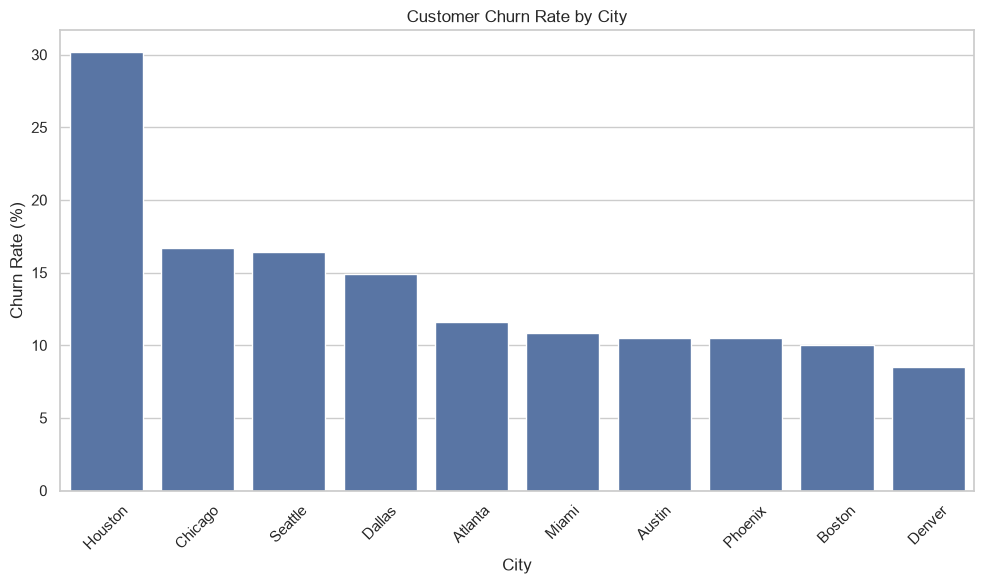

In [41]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=city_summary,
    x="city",
    y="churn_rate"
)

plt.title("Customer Churn Rate by City")
plt.xlabel("City")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Category vs return rate

In [42]:
orders_products = orders.merge(
    products[
        [
            "product_id",
            "product_name",
            "category",
            "list_price"
        ]
    ],
    on="product_id",
    how="left"
)

orders_products.head()

,order_id,customer_id,product_id,order_date,channel,quantity,unit_price,discount_pct,returned,status,product_name,category,list_price
0,50000,10001,1012,2025-09-30,android,1,15.0,15.0,0,delivered,Cable Kit,Accessories,15.0
1,50001,10001,1003,2026-02-26,web,1,59.0,0.0,0,delivered,Desk Speaker Mini,Audio,59.0
2,50002,10001,1013,2025-10-03,web,1,34.0,0.0,0,delivered,BrewGo Travel Mug,Kitchen,34.0
3,50003,10002,1009,2025-11-16,ios,1,69.0,10.0,1,returned,Desk Lamp Pro,Home,69.0
4,50004,10002,1009,2026-07-15,ios,1,69.0,0.0,0,delivered,Desk Lamp Pro,Home,69.0


In [43]:
print("Total orders:", len(orders_products))

print(
    "Orders without category:",
    orders_products["category"].isna().sum()
)

Total orders: 3388
Orders without category: 0


In [44]:
category_returns = (
    orders_products
    .groupby("category")
    .agg(
        total_orders=("order_id", "count"),
        returned_orders=("returned", "sum"),
        return_rate=("returned", "mean")
    )
    .reset_index()
)

category_returns["return_rate"] = (
    category_returns["return_rate"] * 100
)

category_returns

,category,total_orders,returned_orders,return_rate
0,Accessories,680,30,4.411765
1,Audio,646,36,5.572755
2,Home,653,52,7.963247
3,Kitchen,720,171,23.750000
4,Wearables,689,54,7.837446


In [45]:
category_returns

,category,total_orders,returned_orders,return_rate
0,Accessories,680,30,4.411765
1,Audio,646,36,5.572755
2,Home,653,52,7.963247
3,Kitchen,720,171,23.750000
4,Wearables,689,54,7.837446


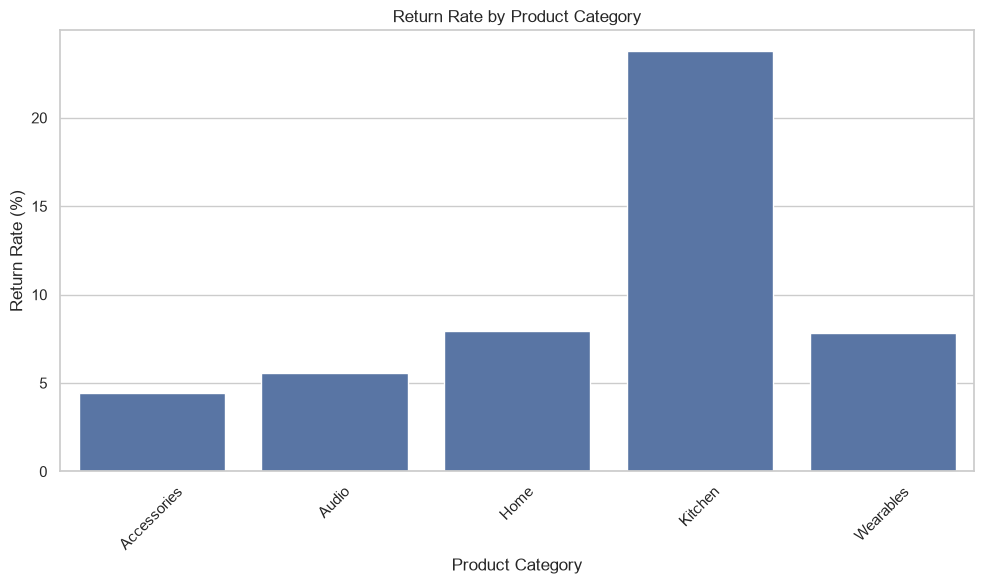

In [46]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_returns,
    x="category",
    y="return_rate"
)

plt.title("Return Rate by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Return Rate (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

 Price Distribution and Outlier Detection

In [47]:
products["list_price"].describe()

count     15.000000
mean      78.066667
std       52.258242
min       15.000000
25%       36.500000
50%       69.000000
75%      104.000000
max      199.000000
Name: list_price, dtype: float64

In [48]:
Q1 = products["list_price"].quantile(0.25)
Q3 = products["list_price"].quantile(0.75)

IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 36.5
Q3: 104.0
IQR: 67.5


In [49]:
lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -64.75
Upper Bound: 205.25


In [50]:
price_outliers = products[
    (products["list_price"] < lower_bound) |
    (products["list_price"] > upper_bound)
]

price_outliers[
    [
        "product_id",
        "product_name",
        "category",
        "list_price"
    ]
]

,product_id,product_name,category,list_price


In [51]:
print("Number of price outliers:", len(price_outliers))

Number of price outliers: 0


In [52]:
outlier_percentage = (
    len(price_outliers) / len(products)
) * 100

print(f"Price outlier percentage: {outlier_percentage:.2f}%")

Price outlier percentage: 0.00%


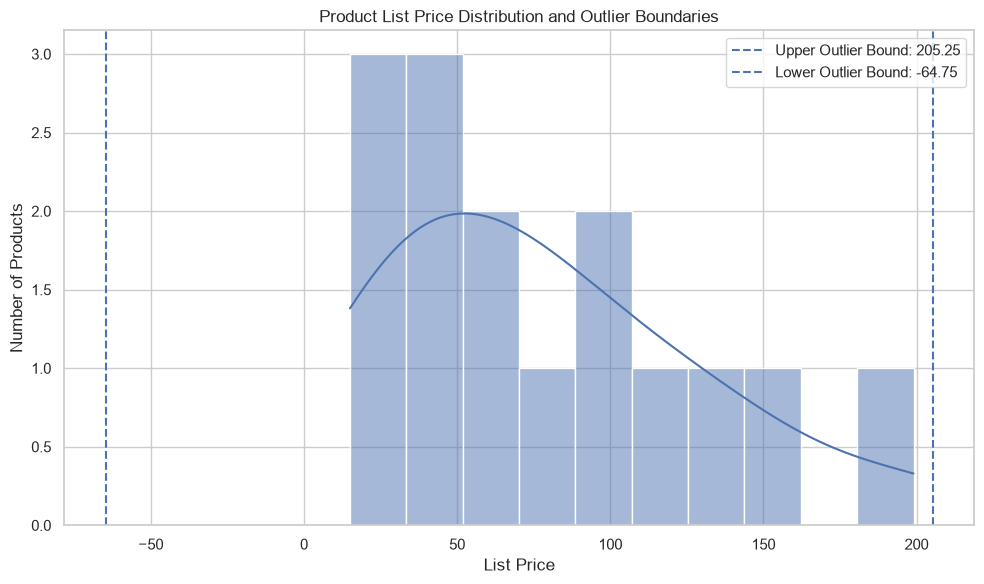

In [53]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=products,
    x="list_price",
    bins=10,
    kde=True
)

plt.axvline(
    upper_bound,
    linestyle="--",
    label=f"Upper Outlier Bound: {upper_bound:.2f}"
)

plt.axvline(
    lower_bound,
    linestyle="--",
    label=f"Lower Outlier Bound: {lower_bound:.2f}"
)

plt.title("Product List Price Distribution and Outlier Boundaries")
plt.xlabel("List Price")
plt.ylabel("Number of Products")

plt.legend()
plt.tight_layout()
plt.show()

In [54]:
price_outliers[
    [
        "product_id",
        "product_name",
        "category",
        "list_price"
    ]
].sort_values(
    "list_price",
    ascending=False
)

,product_id,product_name,category,list_price


#  Station C - Statistics

	Measures of center and spread for order value and for customer order-count.

1. Order Value — Measures of Center and Spread

In [55]:
orders_clean["order_value"] = (
    orders_clean["quantity"]
    * orders_clean["unit_price"]
    * (1 - orders_clean["discount_pct"] / 100)
)

orders_clean["order_value"].describe()

count    3388.000000
mean       86.572565
std        66.730621
min        12.750000
25%        34.000000
50%        69.000000
75%       119.000000
max       597.000000
Name: order_value, dtype: float64

In [56]:
order_value_stats = pd.DataFrame({
    "Metric": [
        "Mean",
        "Median",
        "Standard Deviation",
        "Minimum",
        "Maximum"
    ],
    "Value": [
        orders_clean["order_value"].mean(),
        orders_clean["order_value"].median(),
        orders_clean["order_value"].std(),
        orders_clean["order_value"].min(),
        orders_clean["order_value"].max()
    ]
})

order_value_stats

,Metric,Value
0,Mean,86.572565
1,Median,69.000000
2,Standard Deviation,66.730621
3,Minimum,12.750000
4,Maximum,597.000000


 Customer Order Count — Measures of Center and Spread

In [57]:
customer_order_count = (
    orders_clean
    .groupby("customer_id")
    .size()
    .reset_index(name="order_count")
)

customer_order_count.head()

,customer_id,order_count
0,10001,3
1,10002,7
2,10003,3
3,10004,7
4,10005,4


In [58]:
customer_order_count_stats = pd.DataFrame({
    "Metric": [
        "Mean",
        "Median",
        "Standard Deviation",
        "Minimum",
        "Maximum"
    ],
    "Value": [
        customer_order_count["order_count"].mean(),
        customer_order_count["order_count"].median(),
        customer_order_count["order_count"].std(),
        customer_order_count["order_count"].min(),
        customer_order_count["order_count"].max()
    ]
})

customer_order_count_stats

,Metric,Value
0,Mean,3.981199
1,Median,4.000000
2,Standard Deviation,2.275108
3,Minimum,1.000000
4,Maximum,25.000000


2.	One association view (correlation or grouped rates) with a caution about causation.

In [59]:
customer_stats = customers_clean[
    ["customer_id", "churned"]
].merge(
    customer_order_count,
    on="customer_id",
    how="left"
)

customer_stats["order_count"] = (
    customer_stats["order_count"]
    .fillna(0)
)

customer_stats.head()

,customer_id,churned,order_count
0,10001,0,3.0
1,10002,0,7.0
2,10003,0,3.0
3,10004,0,7.0
4,10005,0,4.0


In [60]:
order_churn_correlation = customer_stats[
    ["order_count", "churned"]
].corr()

order_churn_correlation

,order_count,churned
order_count,1.000000,-0.271574
churned,-0.271574,1.000000


3.Hypothesis tests

Hypothesis Test 1 — City Churn Rate vs Everyone Else

In [61]:
selected_city = "Houston"

city_test_data = customers_clean.copy()

city_test_data["city_group"] = np.where(
    city_test_data["city"] == selected_city,
    selected_city,
    "Other cities"
)

city_test_data.groupby("city_group")["churned"].agg(
    ["count", "sum", "mean"]
)

,count,sum,mean
city_group,,,
Houston,189,57,0.301587
Other cities,673,86,0.127786


In [63]:
%pip install statsmodels

  Using cached scipy-1.18.1-cp312-cp312-win_amd64.whl.metadata (61 kB)
  Using cached narwhals-2.26.0-py3-none-any.whl.metadata (15 kB)
  Using cached wrapt-2.4.1-cp312-cp312-win_amd64.whl.metadata (7.6 kB)
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   --- ------------------------------------ 1.0/11.3 MB 10.1 MB/s eta 0:00:02
   ---------- ----------------------------- 2.9/11.3 MB 8.8 MB/s eta 0:00:01
   ------------ --------------------------- 3.7/11.3 MB 6.8 MB/s eta 0:00:02
   ------------ --------------------------- 3.7/11.3 MB 6.8 MB/s eta 0:00:02
   ------------- -------------------------- 3.9/11.3 MB 4.1 MB/s eta 0:00:02
   ------------- -------------------------- 3.9/11.3 MB 4.1 MB/s eta 0:00:02
   -------------- ------------------------- 4.2/11.3 MB 3.2 MB/s eta 0:00:03
   -------------- ------------------------- 4.2/11.3 MB 3.2 MB/s eta 0:00:03
   --------------- ------------------------ 4.5/11.3 MB 2.4 MB/s eta 0:00:03
   --------------- ----------


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [64]:
from statsmodels.stats.proportion import proportions_ztest

In [65]:
city_counts = (
    city_test_data
    .groupby("city_group")["churned"]
    .agg(["sum", "count"])
)

city_counts

,sum,count
city_group,,
Houston,57,189
Other cities,86,673


In [66]:
successes = city_counts["sum"].values
observations = city_counts["count"].values

z_stat, p_value = proportions_ztest(
    successes,
    observations
)

print("Z-statistic:", z_stat)
print("P-value:", p_value)

Z-statistic: 5.675610010480413
P-value: 1.3819529652528453e-08


City Churn Hypothesis Test

In [67]:
city_counts = (
    city_test_data
    .groupby("city_group")["churned"]
    .agg(["sum", "count"])
)

city_counts

,sum,count
city_group,,
Houston,57,189
Other cities,86,673


In [68]:
successes = city_counts["sum"].values
observations = city_counts["count"].values

z_stat, p_value = proportions_ztest(
    successes,
    observations
)

print("Z-statistic:", z_stat)
print("P-value:", p_value)

Z-statistic: 5.675610010480413
P-value: 1.3819529652528453e-08


In [69]:
city_rates = (
    city_test_data
    .groupby("city_group")["churned"]
    .mean()
    * 100
)

city_rates

city_group
Houston         30.158730
Other cities    12.778603
Name: churned, dtype: float64

In [70]:
city_rate_difference = (
    city_rates[selected_city]
    - city_rates["Other cities"]
)

print(
    f"Churn rate in {selected_city}: "
    f"{city_rates[selected_city]:.2f}%"
)

print(
    f"Churn rate in other cities: "
    f"{city_rates['Other cities']:.2f}%"
)

print(
    f"Difference: "
    f"{city_rate_difference:.2f} percentage points"
)

Churn rate in Houston: 30.16%
Churn rate in other cities: 12.78%
Difference: 17.38 percentage points


In [71]:
alpha = 0.05

if p_value < alpha:
    conclusion = (
        f"The churn rate in {selected_city} is statistically "
        f"different from the churn rate in other cities."
    )
else:
    conclusion = (
        f"There is not enough statistical evidence to conclude "
        f"that the churn rate in {selected_city} differs from "
        f"the churn rate in other cities."
    )

print(conclusion)

The churn rate in Houston is statistically different from the churn rate in other cities.


	Return rate for one category versus the other categories.

In [72]:
selected_category = category_returns.iloc[0]["category"]

print("Selected category:", selected_category)
print(
    "Return rate:",
    category_returns.iloc[0]["return_rate"]
)

Selected category: Accessories
Return rate: 4.411764705882353


In [73]:
category_test_data = orders_products.copy()

category_test_data["category_group"] = np.where(
    category_test_data["category"] == selected_category,
    selected_category,
    "Other categories"
)

category_test_data.groupby("category_group")["returned"].agg(
    ["count", "sum", "mean"]
)

,count,sum,mean
category_group,,,
Accessories,680,30,0.044118
Other categories,2708,313,0.115583


In [74]:
category_counts = (
    category_test_data
    .groupby("category_group")["returned"]
    .agg(["sum", "count"])
)

successes = category_counts["sum"].values
observations = category_counts["count"].values

z_stat_category, p_value_category = proportions_ztest(
    successes,
    observations
)

print("Z-statistic:", z_stat_category)
print("P-value:", p_value_category)

Z-statistic: -5.5234203443747205
P-value: 3.324630552289587e-08


In [75]:
category_rates = (
    category_test_data
    .groupby("category_group")["returned"]
    .mean()
    * 100
)

category_rates

category_group
Accessories          4.411765
Other categories    11.558346
Name: returned, dtype: float64

In [76]:
category_rate_difference = (
    category_rates[selected_category]
    - category_rates["Other categories"]
)

print(
    f"Return rate for {selected_category}: "
    f"{category_rates[selected_category]:.2f}%"
)

print(
    f"Return rate for other categories: "
    f"{category_rates['Other categories']:.2f}%"
)

print(
    f"Difference: "
    f"{category_rate_difference:.2f} percentage points"
)

Return rate for Accessories: 4.41%
Return rate for other categories: 11.56%
Difference: -7.15 percentage points


In [77]:
alpha = 0.05

if p_value_category < alpha:
    category_conclusion = (
        f"The return rate for {selected_category} is "
        f"statistically different from the return rate "
        f"for other categories."
    )
else:
    category_conclusion = (
        f"There is not enough statistical evidence to conclude "
        f"that the return rate for {selected_category} differs "
        f"from the return rate for other categories."
    )

print(category_conclusion)

The return rate for Accessories is statistically different from the return rate for other categories.


City:

H0: The churn rate in Houston is equal to the churn rate in other cities.
Test used: Two-proportion z-test.
P-value: 1.38 × 10⁻⁸.
 Houston's churn rate is 30.16%, compared with 12.78% in other cities, a difference of 17.38 percentage points. This indicates that Houston has a substantially higher observed churn rate and may warrant further investigation. The result shows an association and does not establish that location causes churn.

Category:

H0: The return rate for Accessories is equal to the return rate for other categories.
Test used: Two-proportion z-test.
P-value: 3.32 × 10⁻⁸.
Accessories have a return rate of 4.41%, compared with 11.56% for other categories, a difference of 7.15 percentage points. This indicates that Accessories have a substantially lower observed return rate than other categories. The result shows an association and does not establish that category causes returns.


# Station -D  Features and Supervised Models

In [93]:
print("customers_clean columns:")
print(customers_clean.columns.tolist())

print("\norders_clean columns:")
print(orders_clean.columns.tolist())

print("\nsupport_tickets columns:")
print(support_tickets.columns.tolist())

customers_clean columns:
['customer_id', 'first_name', 'last_name', 'email', 'phone', 'city', 'state', 'signup_date', 'plan', 'age', 'last_active_date', 'churned', 'email_valid', 'phone_clean']

orders_clean columns:
['order_id', 'customer_id', 'product_id', 'order_date', 'channel', 'quantity', 'unit_price', 'discount_pct', 'returned', 'status', 'list_price', 'order_value']

support_tickets columns:
['ticket_id', 'customer_id', 'order_id', 'created_at', 'ticket_type', 'priority', 'raw_message', 'resolved']


In [94]:
print("model_data exists:", "model_data" in globals())

model_data exists: True


In [95]:
print(model_data.columns.tolist())

['customer_id', 'churned', 'plan', 'city', 'order_count_x', 'total_spend_x', 'return_rate_x', 'recency_days_x', 'order_count_y', 'total_spend_y', 'return_rate_y', 'recency_days_y']


In [96]:
cutoff_date = pd.Timestamp("2026-06-01")

print("Feature cutoff date:", cutoff_date)

Feature cutoff date: 2026-06-01 00:00:00


In [97]:
orders_features = orders_clean.copy()

orders_features["order_date"] = pd.to_datetime(
    orders_features["order_date"]
)

orders_features = orders_features[
    orders_features["order_date"] <= cutoff_date
].copy()

print("Orders available by cutoff:", len(orders_features))

Orders available by cutoff: 2679


In [98]:
orders_features["net_revenue"] = np.where(
    orders_features["returned"] == 1,
    0,
    orders_features["quantity"]
    * orders_features["unit_price"]
    * (1 - orders_features["discount_pct"] / 100)
)

orders_features[
    ["order_id", "customer_id", "net_revenue"]
].head()

,order_id,customer_id,net_revenue
0,50000,10001,12.75
1,50001,10001,59.00
2,50002,10001,34.00
3,50003,10002,0.00
5,50005,10002,0.00


In [99]:
customer_order_features = (
    orders_features
    .groupby("customer_id")
    .agg(
        order_count=("order_id", "count"),
        total_spend=("net_revenue", "sum"),
        return_count=("returned", "sum"),
        last_order_date=("order_date", "max")
    )
    .reset_index()
)

customer_order_features.head()

,customer_id,order_count,total_spend,return_count,last_order_date
0,10001,3,105.75,0,2026-02-26
1,10002,6,357.10,3,2025-12-21
2,10003,2,82.65,0,2026-02-02
3,10004,6,706.35,1,2026-05-24
4,10005,4,218.05,2,2026-05-25


In [100]:
customer_order_features["return_rate"] = (
    customer_order_features["return_count"]
    / customer_order_features["order_count"]
)

customer_order_features.head()

,customer_id,order_count,total_spend,return_count,last_order_date,return_rate
0,10001,3,105.75,0,2026-02-26,0.000000
1,10002,6,357.10,3,2025-12-21,0.500000
2,10003,2,82.65,0,2026-02-02,0.000000
3,10004,6,706.35,1,2026-05-24,0.166667
4,10005,4,218.05,2,2026-05-25,0.500000


In [101]:
customer_order_features["recency_days"] = (
    cutoff_date
    - customer_order_features["last_order_date"]
).dt.days

customer_order_features[
    ["customer_id", "last_order_date", "recency_days"]
].head()

,customer_id,last_order_date,recency_days
0,10001,2026-02-26,95
1,10002,2025-12-21,162
2,10003,2026-02-02,119
3,10004,2026-05-24,8
4,10005,2026-05-25,7


In [102]:
support_features = support_tickets.copy()

support_features["created_at"] = pd.to_datetime(
    support_features["created_at"]
)

support_features = support_features[
    support_features["created_at"] <= cutoff_date
].copy()

print(
    "Support tickets available by cutoff:",
    len(support_features)
)

Support tickets available by cutoff: 399


In [103]:
ticket_features = (
    support_features
    .groupby("customer_id")
    .size()
    .reset_index(name="ticket_count")
)

ticket_features.head()

,customer_id,ticket_count
0,10003,2
1,10006,2
2,10009,2
3,10010,1
4,10012,1


In [105]:
model_data = customers_clean[
    [
        "customer_id",
        "churned",
        "plan",
        "city"
    ]
].copy()

model_data = model_data.merge(
    customer_order_features[
        [
            "customer_id",
            "order_count",
            "total_spend",
            "return_rate",
            "recency_days"
        ]
    ],
    on="customer_id",
    how="left"
)

model_data = model_data.merge(
    ticket_features,
    on="customer_id",
    how="left"
)

model_data.head()

,customer_id,churned,plan,city,order_count,total_spend,return_rate,recency_days,ticket_count
0,10001,0,free,Boston,3.0,105.75,0.000000,95.0,NaN
1,10002,0,plus,Chicago,6.0,357.10,0.500000,162.0,NaN
2,10003,0,pro,Austin,2.0,82.65,0.000000,119.0,2.0
3,10004,0,free,Houston,6.0,706.35,0.166667,8.0,NaN
4,10005,0,free,Chicago,4.0,218.05,0.500000,7.0,NaN


In [106]:
model_data["order_count"] = (
    model_data["order_count"].fillna(0)
)

model_data["total_spend"] = (
    model_data["total_spend"].fillna(0)
)

model_data["return_rate"] = (
    model_data["return_rate"].fillna(0)
)

model_data["ticket_count"] = (
    model_data["ticket_count"].fillna(0)
)

In [107]:
max_recency = customer_order_features["recency_days"].max()

model_data["recency_days"] = (
    model_data["recency_days"]
    .fillna(max_recency + 1)
)

In [108]:
model_data.columns.tolist()

['customer_id',
 'churned',
 'plan',
 'city',
 'order_count',
 'total_spend',
 'return_rate',
 'recency_days',
 'ticket_count']

In [109]:
print(
    "last_active_date present:",
    "last_active_date" in model_data.columns
)

last_active_date present: False


In [110]:
X = model_data[
    [
        "order_count",
        "total_spend",
        "return_rate",
        "recency_days",
        "ticket_count",
        "plan",
        "city"
    ]
].copy()

y = model_data["churned"].copy()

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (862, 7)
Target shape: (862,)


In [111]:
y.value_counts()

churned
0    719
1    143
Name: count, dtype: int64

In [112]:
y.value_counts(normalize=True) * 100

churned
0    83.410673
1    16.589327
Name: proportion, dtype: float64

In [114]:
%pip install scikit-learn

  Using cached scikit_learn-1.9.1-cp312-cp312-win_amd64.whl.metadata (9.3 kB)
  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached threadpoolctl-3.7.0-py3-none-any.whl.metadata (24 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
Using cached scikit_learn-1.9.1-cp312-cp312-win_amd64.whl (8.3 MB)
Using cached joblib-1.6.0-py3-none-any.whl (306 kB)
Using cached threadpoolctl-3.7.0-py3-none-any.whl (26 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [115]:
import sklearn

print("scikit-learn version:", sklearn.__version__)

scikit-learn version: 1.9.1


In [116]:
from sklearn.model_selection import train_test_split

In [117]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 689
Testing rows: 173


In [118]:
print("Training churn rate:")
print(f"{y_train.mean() * 100:.2f}%")

print("\nTesting churn rate:")
print(f"{y_test.mean() * 100:.2f}%")

Training churn rate:
16.55%

Testing churn rate:
16.76%


In [119]:
stratify=y

Defining feature types

In [120]:
numeric_features = [
    "order_count",
    "total_spend",
    "return_rate",
    "recency_days",
    "ticket_count"
]

categorical_features = [
    "plan",
    "city"
]

preprocessing pipeline

In [121]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

created baseline using dummy

In [122]:
from sklearn.dummy import DummyClassifier

dummy_model = DummyClassifier(
    strategy="most_frequent"
)

dummy_model.fit(
    X_train,
    y_train
)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
Name,Type,Value
"class_prior_ class_prior_: ndarray of shape (n_classes,) or list of such arraysFrequency of each class observed in `y`. For multioutput classificationproblems, this is computed independently for each output.","ndarray[float64](2,)","[0.83,0.17]"
"classes_ classes_: ndarray of shape (n_classes,) or list of such arraysUnique class labels observed in `y`. For multi-output classificationproblems, this attribute is a list of arrays as each output has anindependent set of possible classes.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X` hasfeature names that are all strings.","ndarray[object](7,)","['order_count','total_spend','return_rate',...,'ticket_count','plan', 'city']"
n_classes_ n_classes_: int or list of intNumber of label for each output.,int,2
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,7
n_outputs_ n_outputs_: intNumber of outputs.,int,1
sparse_output_ sparse_output_: boolTrue if the array returned from predict is to be in sparse CSC format.Is automatically set to True if the input `y` is passed in sparseformat.,bool,False


In [123]:
dummy_predictions = dummy_model.predict(X_test)

print("Dummy baseline predictions:")
print(pd.Series(dummy_predictions).value_counts())

Dummy baseline predictions:
0    173
Name: count, dtype: int64


Evaluate Dummy Baseline

In [124]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

calculating precison and recall

In [125]:
dummy_precision = precision_score(
    y_test,
    dummy_predictions,
    zero_division=0
)

dummy_recall = recall_score(
    y_test,
    dummy_predictions,
    zero_division=0
)

print("Dummy Baseline")
print("----------------")
print(f"Precision: {dummy_precision:.3f}")
print(f"Recall:    {dummy_recall:.3f}")

Dummy Baseline
----------------
Precision: 0.000
Recall:    0.000


Using Strong model

In [126]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

Creating random forest pipeline

In [127]:
rf_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                class_weight="balanced"
            )
        )
    ]
)

Trained randomforest

In [128]:
rf_model.fit(
    X_train,
    y_train
)

print("Random Forest training completed.")

Random Forest training completed.


generated predictions

In [129]:
rf_predictions = rf_model.predict(X_test)

rf_probabilities = rf_model.predict_proba(
    X_test
)[:, 1]

print("Predictions generated.")

Predictions generated.


Random forest evaluation

In [130]:
rf_precision = precision_score(
    y_test,
    rf_predictions,
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    rf_predictions,
    zero_division=0
)

rf_auc = roc_auc_score(
    y_test,
    rf_probabilities
)

print("Random Forest")
print("----------------")
print(f"Precision: {rf_precision:.3f}")
print(f"Recall:    {rf_recall:.3f}")
print(f"ROC-AUC:   {rf_auc:.3f}")

Random Forest
----------------
Precision: 0.405
Recall:    0.586
ROC-AUC:   0.753


Comparing baseline and Randomforest

In [131]:
model_comparison = pd.DataFrame({
    "Model": [
        "Dummy Baseline",
        "Random Forest"
    ],
    "Precision": [
        dummy_precision,
        rf_precision
    ],
    "Recall": [
        dummy_recall,
        rf_recall
    ],
    "ROC-AUC": [
        np.nan,
        rf_auc
    ]
})

model_comparison

,Model,Precision,Recall,ROC-AUC
0,Dummy Baseline,0.000000,0.000000,NaN
1,Random Forest,0.404762,0.586207,0.752754


Confusion matrix

In [132]:
cm = confusion_matrix(
    y_test,
    rf_predictions
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[119  25]
 [ 12  17]]


Classification report

In [133]:
print(
    classification_report(
        y_test,
        rf_predictions,
        target_names=[
            "Not Churned",
            "Churned"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

 Not Churned       0.91      0.83      0.87       144
     Churned       0.40      0.59      0.48        29

    accuracy                           0.79       173
   macro avg       0.66      0.71      0.67       173
weighted avg       0.82      0.79      0.80       173



Error analysis

In [134]:
error_analysis = X_test.copy()

error_analysis["actual_churn"] = y_test.values
error_analysis["predicted_churn"] = rf_predictions

false_negatives = error_analysis[
    (error_analysis["actual_churn"] == 1) &
    (error_analysis["predicted_churn"] == 0)
].copy()

print(
    "Number of churners missed:",
    len(false_negatives)
)

false_negatives.head(10)

Number of churners missed: 12


,order_count,total_spend,return_rate,recency_days,ticket_count,plan,city,actual_churn,predicted_churn
275,1.0,89.00,0.000000,418.0,0.0,plus,Dallas,1,0
232,0.0,0.00,0.000000,504.0,0.0,plus,Houston,1,0
350,2.0,208.00,0.000000,50.0,0.0,free,Houston,1,0
438,3.0,15.00,0.666667,94.0,0.0,plus,Austin,1,0
19,1.0,32.30,0.000000,192.0,1.0,plus,Dallas,1,0
545,4.0,334.55,0.000000,94.0,1.0,free,Chicago,1,0
7,1.0,0.00,1.000000,196.0,0.0,plus,Dallas,1,0
18,5.0,219.20,0.200000,3.0,1.0,pro,Atlanta,1,0
728,1.0,129.00,0.000000,247.0,0.0,pro,Atlanta,1,0
801,1.0,0.00,1.000000,114.0,0.0,free,Dallas,1,0


Missed churners

In [135]:
false_negative_summary = false_negatives[
    [
        "order_count",
        "total_spend",
        "return_rate",
        "recency_days",
        "ticket_count"
    ]
].describe()

false_negative_summary

,order_count,total_spend,return_rate,recency_days,ticket_count
count,12.000000,12.000000,12.000000,12.000000,12.000000
mean,1.750000,96.254167,0.238889,226.500000,0.333333
std,1.544786,110.483342,0.404478,172.626502,0.492366
min,0.000000,0.000000,0.000000,3.000000,0.000000
25%,1.000000,0.000000,0.000000,94.000000,0.000000
50%,1.000000,60.650000,0.000000,194.000000,0.000000
75%,2.250000,148.750000,0.316667,331.000000,1.000000
max,5.000000,334.550000,1.000000,504.000000,1.000000


In [136]:
print("Missed churners by plan:")
print(false_negatives["plan"].value_counts())

print("\nMissed churners by city:")
print(false_negatives["city"].value_counts())

Missed churners by plan:
plan
plus    7
free    3
pro     2
Name: count, dtype: int64

Missed churners by city:
city
Dallas     5
Houston    3
Atlanta    2
Austin     1
Chicago    1
Name: count, dtype: int64


In [137]:
model_comparison

,Model,Precision,Recall,ROC-AUC
0,Dummy Baseline,0.000000,0.000000,NaN
1,Random Forest,0.404762,0.586207,0.752754


In [138]:
print("Number of churners missed:", len(false_negatives))

Number of churners missed: 12


In [139]:
false_negative_summary

,order_count,total_spend,return_rate,recency_days,ticket_count
count,12.000000,12.000000,12.000000,12.000000,12.000000
mean,1.750000,96.254167,0.238889,226.500000,0.333333
std,1.544786,110.483342,0.404478,172.626502,0.492366
min,0.000000,0.000000,0.000000,3.000000,0.000000
25%,1.000000,0.000000,0.000000,94.000000,0.000000
50%,1.000000,60.650000,0.000000,194.000000,0.000000
75%,2.250000,148.750000,0.316667,331.000000,1.000000
max,5.000000,334.550000,1.000000,504.000000,1.000000


# Error Analysis

The Random Forest model achieved a precision of 40.5%, recall of 58.6%, and ROC-AUC of 0.753, compared with the Dummy Classifier baseline, which had zero precision and recall for the churn class.

For an outreach use case, the model identifies approximately 59% of the customers who actually churned, while approximately 41% of customers identified as churners were actually churners. The ROC-AUC of 0.753 indicates that the model has useful ability to distinguish between churned and non-churned customers.

The model missed 12 actual churners. These missed customers had, on average, 1.75 orders, 96.25 in net spend, a 23.89% return rate, 226.5 days of recency, and 0.33 support tickets. This suggests that some churners may have relatively low purchasing activity and long periods since their last order, making them harder for the model to identify consistently.

The model should therefore be treated as an outreach prioritization tool rather than a definitive prediction of whether an individual customer will churn.

# Station E - Unsupervised

In [140]:
cluster_data = model_data[
    [
        "order_count",
        "total_spend",
        "return_rate",
        "recency_days",
        "ticket_count"
    ]
].copy()

cluster_data.head()

,order_count,total_spend,return_rate,recency_days,ticket_count
0,3.0,105.75,0.000000,95.0,0.0
1,6.0,357.10,0.500000,162.0,0.0
2,2.0,82.65,0.000000,119.0,2.0
3,6.0,706.35,0.166667,8.0,0.0
4,4.0,218.05,0.500000,7.0,0.0


Scale the Features

In [141]:
from sklearn.preprocessing import StandardScaler

cluster_scaler = StandardScaler()

X_cluster = cluster_scaler.fit_transform(
    cluster_data
)

print("Cluster feature shape:", X_cluster.shape)

Cluster feature shape: (862, 5)


In [142]:
from sklearn.cluster import KMeans

inertia_values = []

k_values = range(2, 8)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_cluster)
    
    inertia_values.append(
        kmeans.inertia_
    )

elbow_results = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertia_values
})

elbow_results

,k,inertia
0,2,3005.647667
1,3,2393.316515
2,4,1841.743263
3,5,1525.068427
4,6,1333.078051
5,7,1192.375101


Plot the Elbow

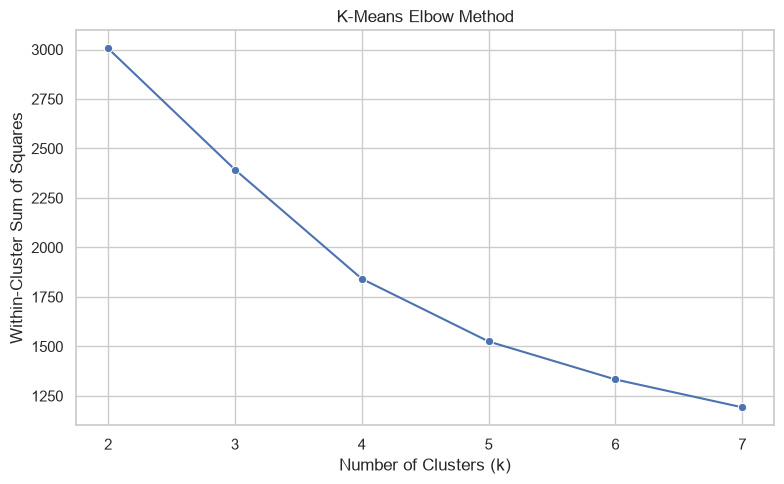

In [143]:
plt.figure(figsize=(8, 5))

sns.lineplot(
    data=elbow_results,
    x="k",
    y="inertia",
    marker="o"
)

plt.title("K-Means Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Within-Cluster Sum of Squares")

plt.tight_layout()
plt.show()

In [144]:
from sklearn.metrics import silhouette_score

silhouette_results = []

for k in range(2, 8):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_cluster)
    
    score = silhouette_score(
        X_cluster,
        labels
    )
    
    silhouette_results.append({
        "k": k,
        "silhouette_score": score
    })

silhouette_results = pd.DataFrame(
    silhouette_results
)

silhouette_results

,k,silhouette_score
0,2,0.278896
1,3,0.317907
2,4,0.311209
3,5,0.310376
4,6,0.337989
5,7,0.330296


select best k value

In [145]:
best_k = silhouette_results.loc[
    silhouette_results["silhouette_score"].idxmax(),
    "k"
]

print("Selected k:", best_k)

Selected k: 6


K-means model

In [146]:
final_kmeans = KMeans(
    n_clusters=int(best_k),
    random_state=42,
    n_init=10
)

kmeans_labels = final_kmeans.fit_predict(X_cluster)

print("Number of clusters:", best_k)

Number of clusters: 6


Assign cluster labels

In [147]:
cluster_data["kmeans_cluster"] = kmeans_labels

cluster_data["kmeans_cluster"].value_counts().sort_index()

kmeans_cluster
0    299
1    121
2    224
3    113
4     75
5     30
Name: count, dtype: int64

 K-Means Cluster Profiles


In [148]:
kmeans_profile = (
    cluster_data
    .groupby("kmeans_cluster")[
        [
            "order_count",
            "total_spend",
            "return_rate",
            "recency_days",
            "ticket_count"
        ]
    ]
    .mean()
    .round(2)
)

kmeans_profile

,order_count,total_spend,return_rate,recency_days,ticket_count
kmeans_cluster,,,,,
0,2.02,169.40,0.00,88.40,0.20
1,3.60,182.16,0.34,78.39,0.33
2,5.03,452.78,0.05,75.68,0.53
3,0.82,59.93,0.00,408.82,0.11
4,4.85,377.43,0.09,79.85,2.19
5,1.07,0.00,1.00,173.53,0.10


# K-Means Cluster Interpretation

The K-Means cluster profiles show clear differences in customer behavior.

Cluster 0 has moderate order activity and spending with zero average return rate. Cluster 1 has higher order activity but a higher average return rate. Cluster 2 shows the highest average order count and total spend among the clusters. Cluster 3 represents customers with very low order activity, low spending, and high recency. Cluster 4 has relatively high order activity and spending along with the highest average support-ticket count. Cluster 5 has low order activity, zero average net spend, and a 100% average return rate.

These differences indicate distinct behavioral groupings in the selected feature space. They are treated as data-driven segments rather than predefined customer personas.

DBScan clustering

In [149]:
from sklearn.cluster import DBSCAN

dbscan_model = DBSCAN(
    eps=0.8,
    min_samples=5
)

dbscan_labels = dbscan_model.fit_predict(X_cluster)

cluster_data["dbscan_cluster"] = dbscan_labels

cluster_data["dbscan_cluster"].value_counts().sort_index()

dbscan_cluster
-1     89
 0    491
 1     27
 2    207
 3     30
 4     13
 5      5
Name: count, dtype: int64

In [150]:
dbscan_summary = (
    cluster_data["dbscan_cluster"]
    .value_counts()
    .sort_index()
    .rename_axis("dbscan_cluster")
    .reset_index(name="customer_count")
)

dbscan_summary

,dbscan_cluster,customer_count
0,-1,89
1,0,491
2,1,27
3,2,207
4,3,30
5,4,13
6,5,5


DBScan cluster profiles

In [155]:
dbscan_profile = (
    cluster_data
    .groupby("dbscan_cluster")[
        [
            "order_count",
            "total_spend",
            "return_rate",
            "recency_days",
            "ticket_count"
        ]
    ]
    .mean()
    .round(2)
)

dbscan_profile

,order_count,total_spend,return_rate,recency_days,ticket_count
dbscan_cluster,,,,,
-1,4.79,403.61,0.26,109.79,1.48
0,2.54,206.98,0.04,149.25,0.00
1,1.07,0.00,1.00,186.93,0.00
2,3.79,289.35,0.05,89.93,1.00
3,4.10,298.17,0.01,62.53,2.00
4,2.00,93.13,0.50,105.77,0.00
5,4.20,318.23,0.48,58.80,0.00


In [153]:
dbscan_checks = []

for eps in [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
    model = DBSCAN(
        eps=eps,
        min_samples=5
    )
    
    labels = model.fit_predict(X_cluster)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_count = (labels == -1).sum()
    
    dbscan_checks.append({
        "eps": eps,
        "clusters": n_clusters,
        "noise_count": noise_count,
        "noise_percentage": round(
            noise_count / len(labels) * 100, 2
        )
    })

dbscan_checks = pd.DataFrame(dbscan_checks)

dbscan_checks

,eps,clusters,noise_count,noise_percentage
0,0.5,21,245,28.42
1,0.6,13,145,16.82
2,0.7,6,110,12.76
3,0.8,6,89,10.32
4,0.9,6,65,7.54
5,1.0,5,44,5.10


# DBSCAN Interpretation

DBSCAN identified six density-based clusters along with a noise group labeled `-1`.

The noise group has relatively high average order count, spending, return rate, and ticket count compared with several identified clusters. These observations were not assigned to a sufficiently dense group under the selected DBSCAN parameters.

The DBSCAN results provide a complementary view of the customer structure. However, the clusters should not be treated as definitive customer personas without further business validation.

Comparing kmeans and dbscan models

In [156]:
kmeans_cluster_counts = (
    cluster_data["kmeans_cluster"]
    .value_counts()
    .sort_index()
    .rename("kmeans_customer_count")
)

dbscan_cluster_counts = (
    cluster_data["dbscan_cluster"]
    .value_counts()
    .sort_index()
    .rename("dbscan_customer_count")
)

print("K-Means cluster counts:")
display(kmeans_cluster_counts)

print("\nDBSCAN cluster counts:")
display(dbscan_cluster_counts)


K-Means cluster counts:


kmeans_cluster
0    299
1    121
2    224
3    113
4     75
5     30
Name: kmeans_customer_count, dtype: int64


DBSCAN cluster counts:


dbscan_cluster
-1     89
 0    491
 1     27
 2    207
 3     30
 4     13
 5      5
Name: dbscan_customer_count, dtype: int64

# Station E Conclusion

K-Means was applied to customer behavioral features consisting of order count, total spend, return rate, recency, and ticket count. The number of clusters was evaluated using the elbow method and silhouette score, and the resulting clusters were profiled using their average feature values.

DBSCAN was then applied to the same standardized feature slice. A sensitivity check across different `eps` values showed that six clusters were consistently produced for `eps` values of 0.7, 0.8, and 0.9. An `eps` value of 0.8 was retained, resulting in six clusters and 10.32% of observations classified as noise.

Overall, both methods reveal differences in customer behavioral patterns. The resulting groups are treated as data-driven behavioral segments rather than predefined personas. Further business validation would be required before using these segments for targeted customer actions.

# Station F - Time Series

In [158]:
import pandas as pd

daily_ops = pd.read_csv("data/csv/daily_ops.csv")

daily_ops.head()

,date,site_visits,orders_count,revenue_usd,support_tickets,promo_flag
0,2025-01-01,4157,114,7172.00,34,0
1,2025-01-02,4418,170,10421.59,24,0
2,2025-01-03,4169,148,10991.89,19,0
3,2025-01-04,5656,218,15004.27,25,0
4,2025-01-05,5402,228,17047.79,35,0


Preparing the Daily Time Series

In [159]:
daily_ts = daily_ops.copy()

daily_ts["date"] = pd.to_datetime(daily_ts["date"])

daily_ts = (
    daily_ts
    .sort_values("date")
    .reset_index(drop=True)
)

daily_ts.head()

,date,site_visits,orders_count,revenue_usd,support_tickets,promo_flag
0,2025-01-01,4157,114,7172.00,34,0
1,2025-01-02,4418,170,10421.59,24,0
2,2025-01-03,4169,148,10991.89,19,0
3,2025-01-04,5656,218,15004.27,25,0
4,2025-01-05,5402,228,17047.79,35,0


Time-Series Coverage

In [160]:
print("Start date:", daily_ts["date"].min())
print("End date:", daily_ts["date"].max())
print("Number of daily observations:", len(daily_ts))

Start date: 2025-01-01 00:00:00
End date: 2026-08-31 00:00:00
Number of daily observations: 608


Identifying march promo window

In [161]:
march_promo = daily_ts[
    (daily_ts["date"].dt.year == 2026) &
    (daily_ts["date"].dt.month == 3) &
    (daily_ts["promo_flag"] == 1)
]

print("Promo start:", march_promo["date"].min())
print("Promo end:", march_promo["date"].max())
print("Promo days:", len(march_promo))

Promo start: 2026-03-01 00:00:00
Promo end: 2026-03-21 00:00:00
Promo days: 21


 Daily Orders Trend

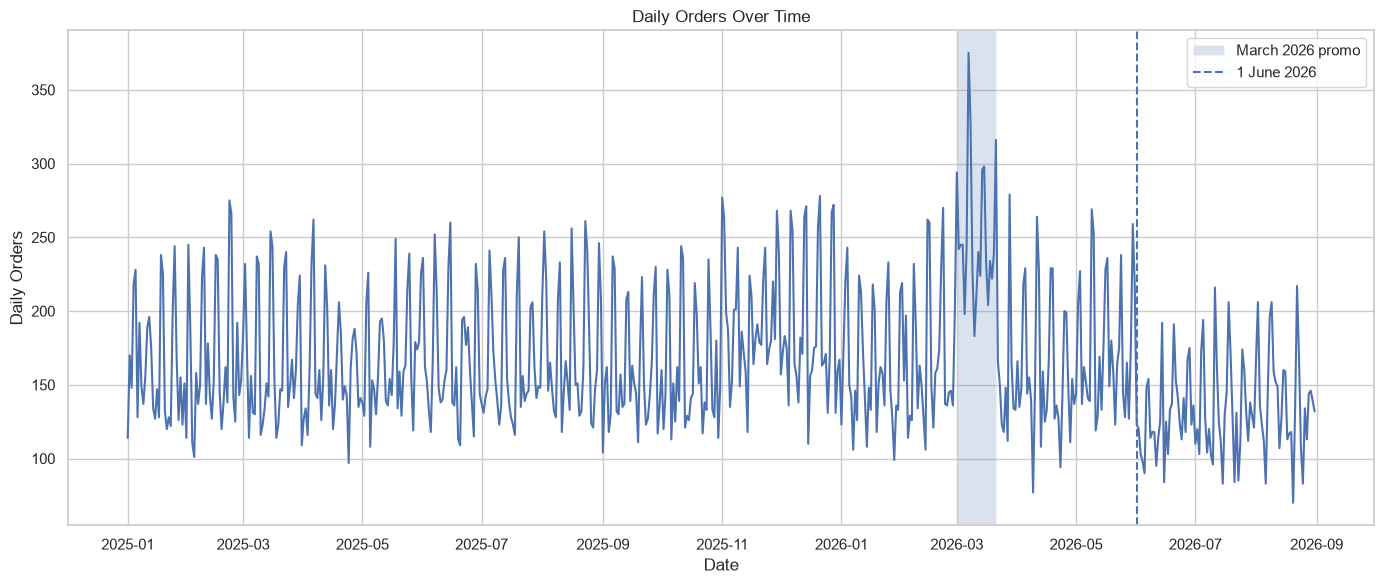

In [162]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=daily_ts,
    x="date",
    y="orders_count"
)

# Mark March 2026 promo window
plt.axvspan(
    pd.Timestamp("2026-03-01"),
    pd.Timestamp("2026-03-21"),
    alpha=0.2,
    label="March 2026 promo"
)

# Mark 1 June 2026
plt.axvline(
    pd.Timestamp("2026-06-01"),
    linestyle="--",
    label="1 June 2026"
)

plt.title("Daily Orders Over Time")
plt.xlabel("Date")
plt.ylabel("Daily Orders")
plt.legend()
plt.tight_layout()
plt.show()

Time-Based Train/Test Split

In [163]:
split_date = pd.Timestamp("2026-06-01")

train_ts = daily_ts[
    daily_ts["date"] < split_date
].copy()

test_ts = daily_ts[
    daily_ts["date"] >= split_date
].copy()

print("Training period:")
print(train_ts["date"].min(), "to", train_ts["date"].max())

print("\nTest period:")
print(test_ts["date"].min(), "to", test_ts["date"].max())

print("\nTraining observations:", len(train_ts))
print("Test observations:", len(test_ts))

Training period:
2025-01-01 00:00:00 to 2026-05-31 00:00:00

Test period:
2026-06-01 00:00:00 to 2026-08-31 00:00:00

Training observations: 516
Test observations: 92


In [164]:
print(
    "Latest training date:",
    train_ts["date"].max()
)

print(
    "Earliest test date:",
    test_ts["date"].min()
)

print(
    "Time order valid:",
    train_ts["date"].max() < test_ts["date"].min()
)

Latest training date: 2026-05-31 00:00:00
Earliest test date: 2026-06-01 00:00:00
Time order valid: True


Naive Forecasting Baseline

In [165]:
test_ts = test_ts.copy()

test_ts["naive_prediction"] = (
    daily_ts["orders_count"]
    .shift(1)
    .loc[test_ts.index]
)

test_ts[
    ["date", "orders_count", "naive_prediction"]
].head()

,date,orders_count,naive_prediction
516,2026-06-01,123,217.0
517,2026-06-02,120,123.0
518,2026-06-03,103,120.0
519,2026-06-04,98,103.0
520,2026-06-05,90,98.0


Evaluating

In [ ]:
from sklearn.metrics import mean_absolute_error

naive_mae = mean_absolute_error(
    test_ts["orders_count"],
    test_ts["naive_prediction"]
)

print("Naive baseline MAE:", round(naive_mae, 2))

Naive baseline MAE: 31.6


Compare before vs after 1stjune

In [168]:
pre_june = daily_ts[
    daily_ts["date"] < pd.Timestamp("2026-06-01")
]

post_june = daily_ts[
    daily_ts["date"] >= pd.Timestamp("2026-06-01")
]

pre_june_mean = pre_june["orders_count"].mean()
post_june_mean = post_june["orders_count"].mean()

change_pct = (
    (post_june_mean - pre_june_mean)
    / pre_june_mean
    * 100
)

print("Average daily orders before 1 June 2026:",
      round(pre_june_mean, 2))

print("Average daily orders from 1 June 2026:",
      round(post_june_mean, 2))

print("Percentage change:",
      round(change_pct, 2), "%")

Average daily orders before 1 June 2026: 171.71
Average daily orders from 1 June 2026: 133.7
Percentage change: -22.14 %


# Station F Conclusion

Average daily orders decreased from **171.71 before 1 June 2026** to **133.70 from 1 June 2026 onward**, a **22.14% decrease**, indicating a noticeable downward level shift after 1 June 2026; however, this descriptive comparison alone does not establish that the change was caused by the June change.

# Station G: Regex

Define Regex Patterns

In [169]:
import re

order_pattern = r"\b(?:ORD[-_ ]?)?\d{4,}\b"

email_pattern = r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b"

phone_pattern = r"(?<!\d)(?:\+?\d{1,3}[-.\s]?)?(?:\(?\d{3}\)?[-.\s]?)?\d{3}[-.\s]?\d{4}(?!\d)"

Display the patterns

In [170]:
print("Order ID pattern:", order_pattern)
print("Email pattern:", email_pattern)
print("Phone pattern:", phone_pattern)

Order ID pattern: \b(?:ORD[-_ ]?)?\d{4,}\b
Email pattern: \b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b
Phone pattern: (?<!\d)(?:\+?\d{1,3}[-.\s]?)?(?:\(?\d{3}\)?[-.\s]?)?\d{3}[-.\s]?\d{4}(?!\d)


Extract from all 520 tickets

In [171]:
support_regex = support_tickets.copy()

support_regex["extracted_order_id"] = (
    support_regex["raw_message"]
    .astype("string")
    .str.extract(f"({order_pattern})", expand=False)
)

support_regex["extracted_email"] = (
    support_regex["raw_message"]
    .astype("string")
    .str.extract(f"({email_pattern})", expand=False)
)

support_regex["extracted_phone"] = (
    support_regex["raw_message"]
    .astype("string")
    .str.extract(f"({phone_pattern})", expand=False)
)

support_regex[
    [
        "ticket_id",
        "extracted_order_id",
        "extracted_email",
        "extracted_phone"
    ]
].head(10)

,ticket_id,extracted_order_id,extracted_email,extracted_phone
0,70000,51230,priya.shah321@yahoo.com,+1-995-822-1877
1,70001,53361,noah.ortiz850@yahoo.com,+1-335-991-8538
2,70002,52080,dev.kim540@yahoo.com,+1-509-856-6229
3,70003,52986,grace.patel765@gmail.com,+1-274-666-6528
4,70004,50475,owen.khan121@yahoo.com,+1-430-627-6266
5,70005,53325,maya.bennett843@pulsecart-mail.com,+1-728-738-8733
6,70006,50837,marcus.ortiz214@outlook.com,+1-314-300-6822
7,70007,51520,imani.bennett397@outlook.com,+1-258-518-7072
8,70008,50321,diego.patel80@yahoo.com,+1-874-708-4283
9,70009,50155,elena.patel42@yahoo.com,+1-373-258-8376


Calculating Hit rate

In [172]:
total_tickets = len(support_regex)

order_hit_rate = (
    support_regex["extracted_order_id"].notna().mean() * 100
)

email_hit_rate = (
    support_regex["extracted_email"].notna().mean() * 100
)

phone_hit_rate = (
    support_regex["extracted_phone"].notna().mean() * 100
)

print("Total tickets:", total_tickets)
print("Order ID hit rate:", round(order_hit_rate, 2), "%")
print("Email hit rate:", round(email_hit_rate, 2), "%")
print("Phone hit rate:", round(phone_hit_rate, 2), "%")

Total tickets: 520
Order ID hit rate: 100.0 %
Email hit rate: 98.08 %
Phone hit rate: 88.85 %


Hit summary

In [173]:
regex_summary = pd.DataFrame({
    "Field": ["Order ID", "Email", "Phone"],
    "Hit Rate (%)": [
        round(order_hit_rate, 2),
        round(email_hit_rate, 2),
        round(phone_hit_rate, 2)
    ]
})

regex_summary

,Field,Hit Rate (%)
0,Order ID,100.00
1,Email,98.08
2,Phone,88.85


# Station H: ANN/CNN

Importing libraries

In [187]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.neural_network import MLPClassifier

Image dataset

In [188]:
base_path = "./data/images"

classes = ["damaged", "normal", "wrong_item"]

dataset_summary = []

for class_name in classes:
    class_path = os.path.join(base_path, class_name)

    image_count = len([
        f for f in os.listdir(class_path)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ])

    dataset_summary.append({
        "Class": class_name,
        "Number of Images": image_count
    })

dataset_summary = pd.DataFrame(dataset_summary)

dataset_summary.loc[len(dataset_summary)] = [
    "Total",
    dataset_summary["Number of Images"].sum()
]

dataset_summary

,Class,Number of Images
0,damaged,80
1,normal,80
2,wrong_item,80
3,Total,240


Load and preprocess image

In [189]:
image_size = (32, 32)

image_data = []
labels = []

for class_name in classes:
    class_path = os.path.join(base_path, class_name)

    for file_name in os.listdir(class_path):

        if file_name.lower().endswith((".png", ".jpg", ".jpeg")):

            file_path = os.path.join(class_path, file_name)

            image = Image.open(file_path).convert("RGB")
            image = image.resize(image_size)

            image_array = np.array(image) / 255.0

            image_data.append(image_array)
            labels.append(class_name)

X_images = np.array(image_data)
y_labels = np.array(labels)

print("Image data shape:", X_images.shape)
print("Label shape:", y_labels.shape)

Image data shape: (240, 32, 32, 3)
Label shape: (240,)


Flatten image pixels

In [192]:

X_flat = X_images.reshape(
    X_images.shape[0],
    -1
)

print("Flattened image shape:", X_flat.shape)


Flattened image shape: (240, 3072)


Encode image classes

In [193]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y_labels)

class_mapping = pd.DataFrame({
    "Encoded Value": range(len(label_encoder.classes_)),
    "Class": label_encoder.classes_
})

class_mapping

,Encoded Value,Class
0,0,damaged
1,1,normal
2,2,wrong_item


Train/Test split

In [194]:
X_train, X_test, y_train, y_test = train_test_split(
    X_flat,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

split_summary = pd.DataFrame({
    "Dataset": ["Training", "Testing", "Total"],
    "Number of Images": [
        len(X_train),
        len(X_test),
        len(X_train) + len(X_test)
    ],
    "Percentage": [
        80,
        20,
        100
    ]
})

split_summary

,Dataset,Number of Images,Percentage
0,Training,192,80
1,Testing,48,20
2,Total,240,100


2-layer ANN

In [195]:

ann_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    max_iter=100,
    random_state=42
)

ann_model.fit(X_train, y_train)

print("ANN training completed.")

ANN training completed.


Generate predictions

In [196]:
y_pred = ann_model.predict(X_test)

print("Number of test predictions:", len(y_pred))

Number of test predictions: 48


Accuracy

In [197]:
accuracy = accuracy_score(y_test, y_pred)

print("ANN Test Accuracy:", round(accuracy * 100, 2), "%")

ANN Test Accuracy: 100.0 %


Classification performance

In [198]:
report = classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_,
    output_dict=True
)

performance_table = pd.DataFrame(report).T

performance_table = performance_table.round(2)

performance_table

,precision,recall,f1-score,support
damaged,1.0,1.0,1.0,16.0
normal,1.0,1.0,1.0,16.0
wrong_item,1.0,1.0,1.0,16.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,48.0
weighted avg,1.0,1.0,1.0,48.0


Confusion matrix visualisation

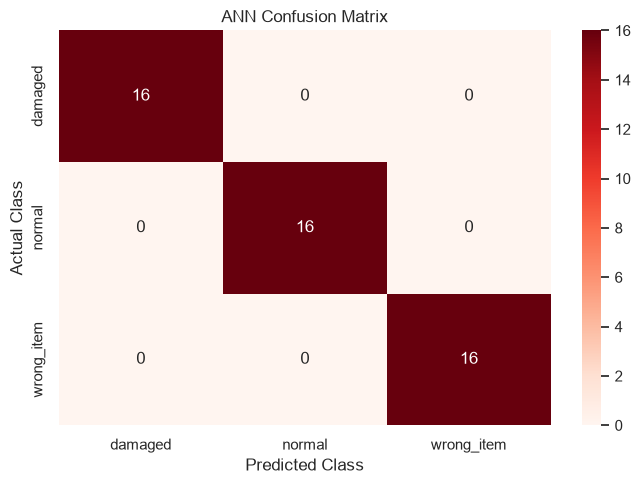

In [202]:
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("ANN Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

Confusion point

In [200]:
confusion_points = []

for i, actual_class in enumerate(label_encoder.classes_):
    for j, predicted_class in enumerate(label_encoder.classes_):

        if i != j and cm[i, j] > 0:
            confusion_points.append({
                "Actual Class": actual_class,
                "Predicted Class": predicted_class,
                "Number of Images": cm[i, j]
            })

if len(confusion_points) == 0:
    print("No classification confusion was observed.")
else:
    confusion_points_table = pd.DataFrame(confusion_points)
    confusion_points_table

No classification confusion was observed.


# Station H Conclusion

A 2-layer ANN was trained on flattened 32 × 32 RGB image pixels using an 80/20 train-test split. The dataset contained **240 images**, with **192 training images and 48 testing images**. The model achieved **100% test accuracy**, with precision, recall, and F1-score of **1.00** for the **damaged, normal, and wrong_item** classes. The confusion matrix showed **no misclassified images**, so no classification confusion was observed among the 48 test images.